<center><h1><b>Upgrade: Long Short-Term Memory (LSTM)</b></h1></center>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import seaborn as sns

In [16]:
# Load dataset
df = pd.read_csv("Processed Datasets/Crime_Weather_Dataset.csv", parse_dates=["Date"])
df = df.sort_values(["Borough", "Date"])

In [17]:
# Add day of week feature
df["day_of_week"] = df["Date"].dt.dayofweek

In [18]:
# Define features and targets
base_features = ["temp", "tempmax", "tempmin", "humidity", "precip", "snow", "windspeed", "visibility", "day_of_week"]

# Define target crime categories
targets = ["Burglary", "Robbery", "Theft", "Total_Crime"]

# Define lag features 
lagged_features = [f"{target}_lag_{lag}" for target in targets for lag in range(1, 4)]

# Final feature list includes both base and lagged features
features = base_features + lagged_features

In [19]:
# Split dates
train_end = "2019-12-31"
test_start = "2020-04-01"
test_end = "2020-04-14"

In [20]:
# Sequence function
def create_sequences(X, y, lookback=7):
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback])
    return np.array(Xs), np.array(ys)

In [21]:
# For saving predictions
all_predictions = {}
results = []

In [22]:
# Process each borough
boroughs = df["Borough"].unique()
for borough in boroughs:
    print(f"Processing {borough}...")

    borough_df = df[df["Borough"] == borough].copy()
    borough_df = borough_df.set_index("Date")

    # Add lag features before train-test split
    for lag in range(1, 4):
        for target in targets:
            borough_df[f"{target}_lag_{lag}"] = borough_df[target].shift(lag)

    # Drop rows with NaNs caused by lagging
    borough_df.dropna(inplace=True)

    # Split
    train = borough_df[:train_end]
    test = borough_df[test_start:test_end]

    # Scale
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train = scaler_X.fit_transform(train[features])
    y_train = scaler_y.fit_transform(train[targets])

    X_train_seq, y_train_seq = create_sequences(X_train, y_train, lookback=7)

    # Build model
    model = Sequential()
    model.add(LSTM(64, input_shape=(7, len(features))))
    model.add(Dense(4))  # 4 outputs
    model.compile(loss="mse", optimizer="adam")
    model.fit(X_train_seq, y_train_seq, epochs=50, verbose=0)

    # Predict sequentially 14 days
    last_7_days = test[features].iloc[:7].values
    input_seq = scaler_X.transform(last_7_days).reshape(1, 7, len(features))

    preds = []
    for i in range(14):
         pred = model.predict(input_seq)[0]
         preds.append(pred)

         if i + 7 < len(test):
             next_input = test[features].iloc[i + 7].values.reshape(1, -1)
             next_scaled = scaler_X.transform(next_input)
         else:
             next_scaled = input_seq[0, -1:].copy()

         input_seq = np.append(input_seq[:, 1:, :], [[next_scaled[0]]], axis=1)

    preds = scaler_y.inverse_transform(preds)
    true = test[targets].values[:14]

    all_predictions[borough] = {
        "pred": preds,
        "true": true
    }

    # Store metrics
    for i, crime in enumerate(targets):
        mae = mean_absolute_error(true[:, i], preds[:, i])
        rmse = np.sqrt(mean_squared_error(true[:, i], preds[:, i]))
        results.append({
            "Borough": borough,
            "Crime": crime,
            "MAE": mae,
            "RMSE": rmse
        })


Processing Camden...


C:\Users\ruibi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\ruibi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


C:\Users\ruibi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\ruibi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


C:\Users\ruibi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\ruibi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


C:\Users\ruibi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [23]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\n=== LSTM Multi-Output Evaluation ===")
print(results_df.sort_values("RMSE"))


=== LSTM Multi-Output Evaluation ===
                   Borough        Crime        MAE       RMSE
9                Greenwich      Robbery   0.741141   0.849573
17  Hammersmith and Fulham      Robbery   0.778416   0.894411
41           Tower Hamlets      Robbery   0.834829   0.897194
25  Kensington and Chelsea      Robbery   1.033986   1.267895
33                Lewisham      Robbery   1.087617   1.275652
45              Wandsworth      Robbery   0.872557   1.280233
29                 Lambeth      Robbery   1.165303   1.391227
5           City of London      Robbery   1.321302   1.466621
1                   Camden      Robbery   1.288615   1.521522
21               Islington      Robbery   1.449899   1.644123
20               Islington     Burglary   1.395303   1.688226
4           City of London     Burglary   1.580499   1.881947
37               Southwark      Robbery   1.774622   1.953832
40           Tower Hamlets     Burglary   1.842226   2.047014
13                 Hackney      

In [24]:
# Reshape the DataFrame before plotting
pivot_mae = results_df.pivot(index='Borough', columns='Crime', values='MAE')
pivot_rmse = results_df.pivot(index='Borough', columns='Crime', values='RMSE')

In [25]:
# Rename the columns to indicate MAE and RMSE
pivot_mae.columns = [f"{crime}_MAE" for crime in pivot_mae.columns]
pivot_rmse.columns = [f"{crime}_RMSE" for crime in pivot_rmse.columns]

In [26]:
# Merge MAE and RMSE into one DataFrame
summary_df = pd.concat([pivot_mae, pivot_rmse], axis=1)

In [27]:
# Reorder columns for clarity
summary_df = summary_df[
    ['Burglary_MAE', 'Burglary_RMSE',
     'Robbery_MAE', 'Robbery_RMSE',
     'Theft_MAE', 'Theft_RMSE',
     'Total_Crime_MAE', 'Total_Crime_RMSE']
]

In [28]:
# Reset index for a clean table
summary_df = summary_df.reset_index()

In [29]:
print("\n=== LSTM Multi-Output Summary by Borough ===")
print(summary_df.sort_values("Total_Crime_RMSE"))


=== LSTM Multi-Output Summary by Borough ===
                   Borough  Burglary_MAE  Burglary_RMSE  Robbery_MAE  \
10           Tower Hamlets      1.842226       2.047014     0.834829   
1           City of London      1.580499       1.881947     1.321302   
8                 Lewisham      2.282091       2.687782     1.087617   
5                Islington      1.395303       1.688226     1.449899   
4   Hammersmith and Fulham      2.391648       2.756600     0.778416   
11              Wandsworth      3.574509       4.478789     0.872557   
9                Southwark      2.677727       3.151651     1.774622   
3                  Hackney      2.483879       3.389141     1.651826   
0                   Camden      2.164942       2.519221     1.288615   
2                Greenwich      3.590131       3.929230     0.741141   
7                  Lambeth      2.902753       3.433054     1.165303   
6   Kensington and Chelsea      1.656095       2.179871     1.033986   
12             Wes

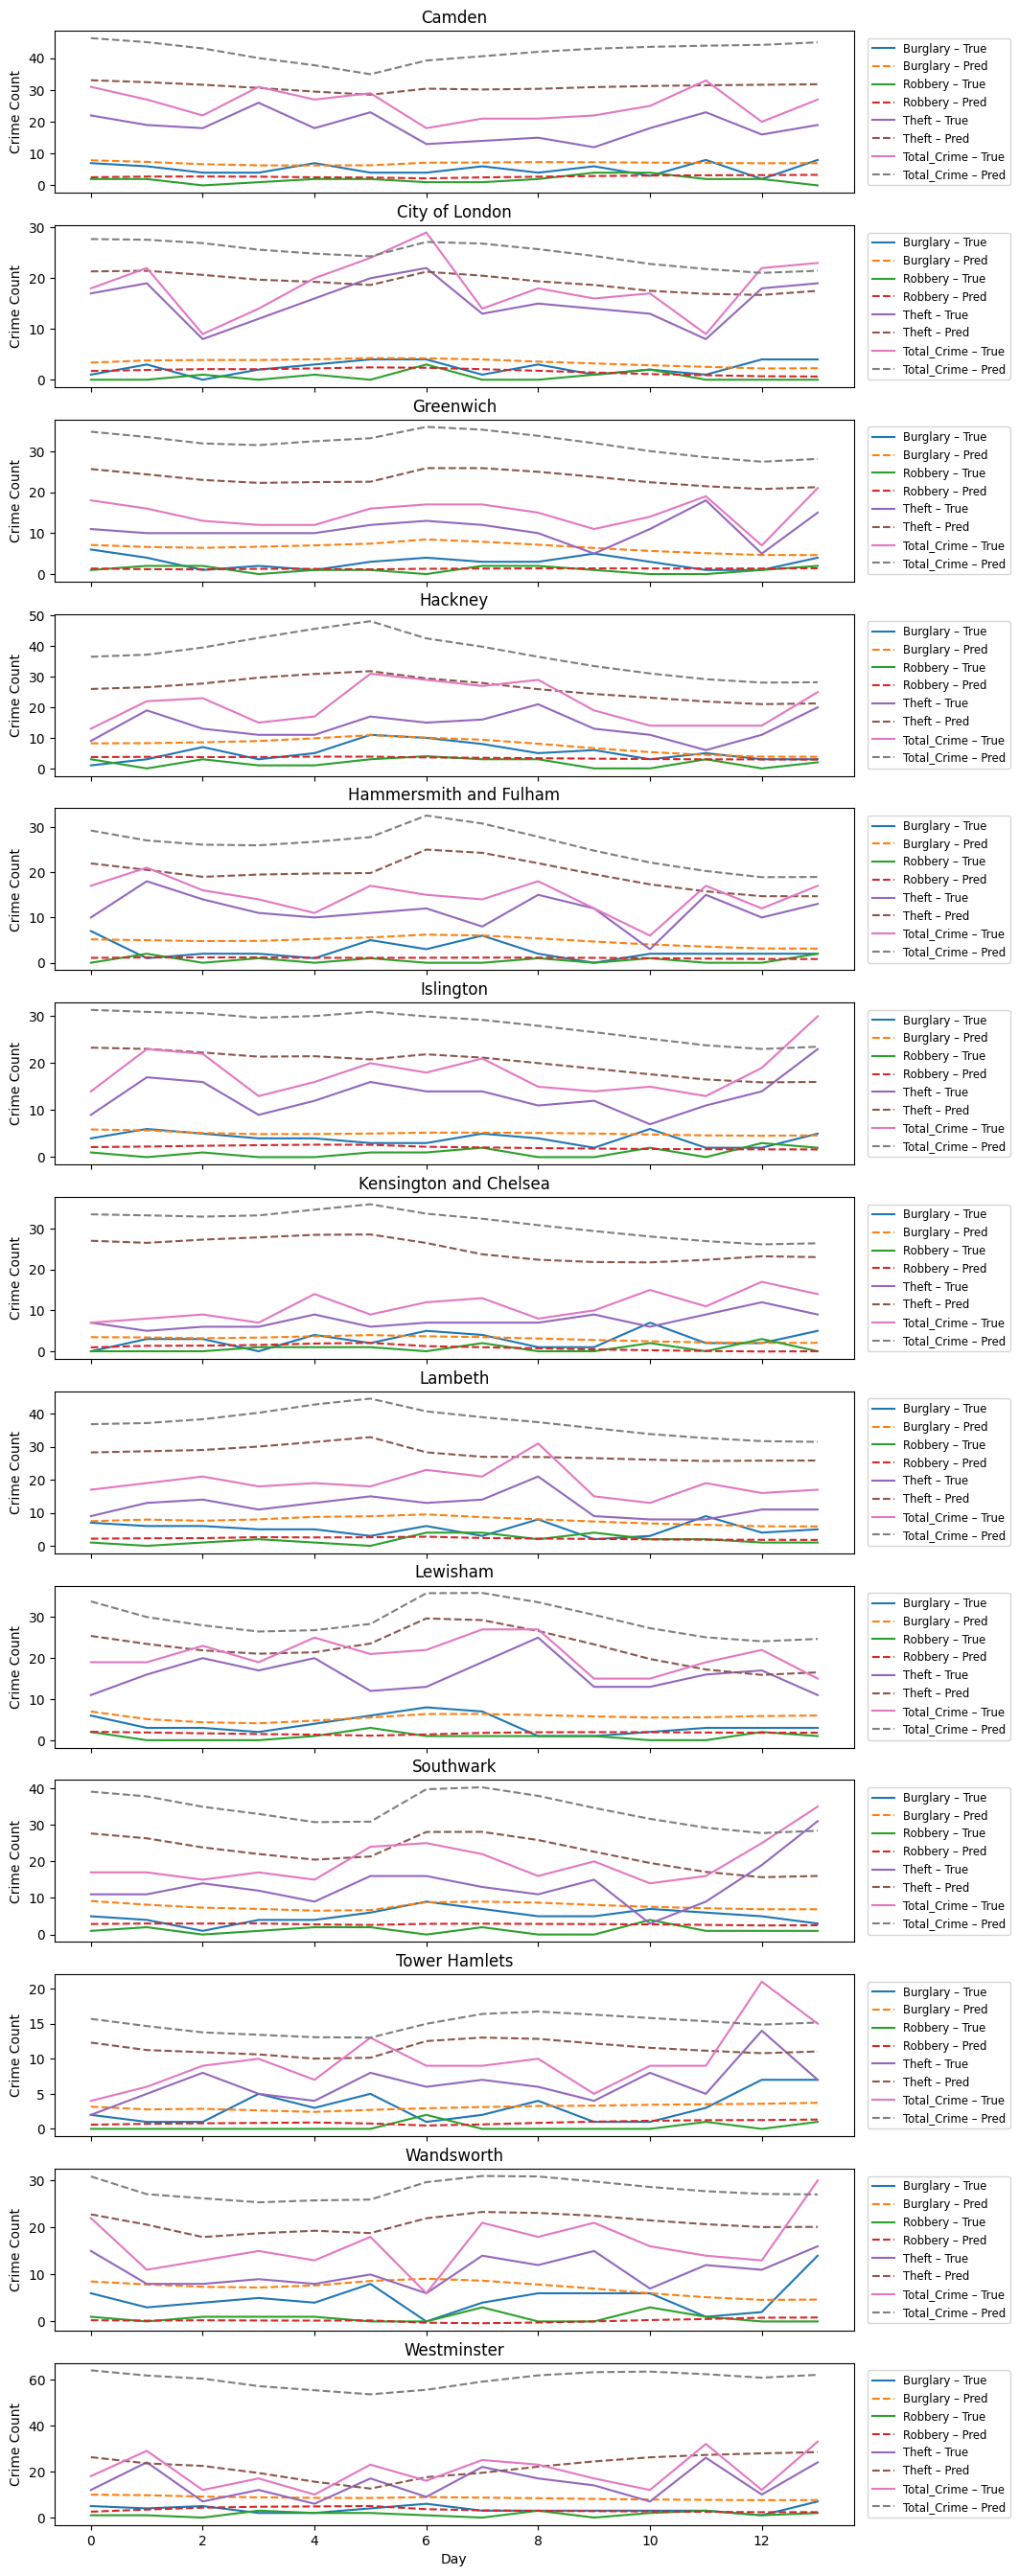

In [35]:
n_rows = len(boroughs)
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=1,
    figsize=(12, 2.6 * n_rows),
    sharex=True
)

# Ensure axes is iterable
if n_rows == 1:
    axes = [axes]

for ax, borough in zip(axes, boroughs):
    preds = all_predictions[borough]["pred"]
    true  = all_predictions[borough]["true"]

    for i, crime in enumerate(targets):
        ax.plot(true[:, i],  linestyle='-',  label=f"{crime} – True")
        ax.plot(preds[:, i], linestyle='--', label=f"{crime} – Pred")

    ax.set_title(borough)
    ax.set_ylabel("Crime Count")

    # Place legend just outside each subplot (on the right, vertically stacked)
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),  # (x, y) → x>1 moves it outside, y=0.5 centers vertically
        frameon=True,
        fontsize="small"
    )

axes[-1].set_xlabel("Day")

# Make room on the right side across all subplots for the legends
fig.subplots_adjust(right=0.82)

plt.savefig("lstm_forecast_all_boroughs_with_legends.png", dpi=300, bbox_inches='tight')
plt.show()

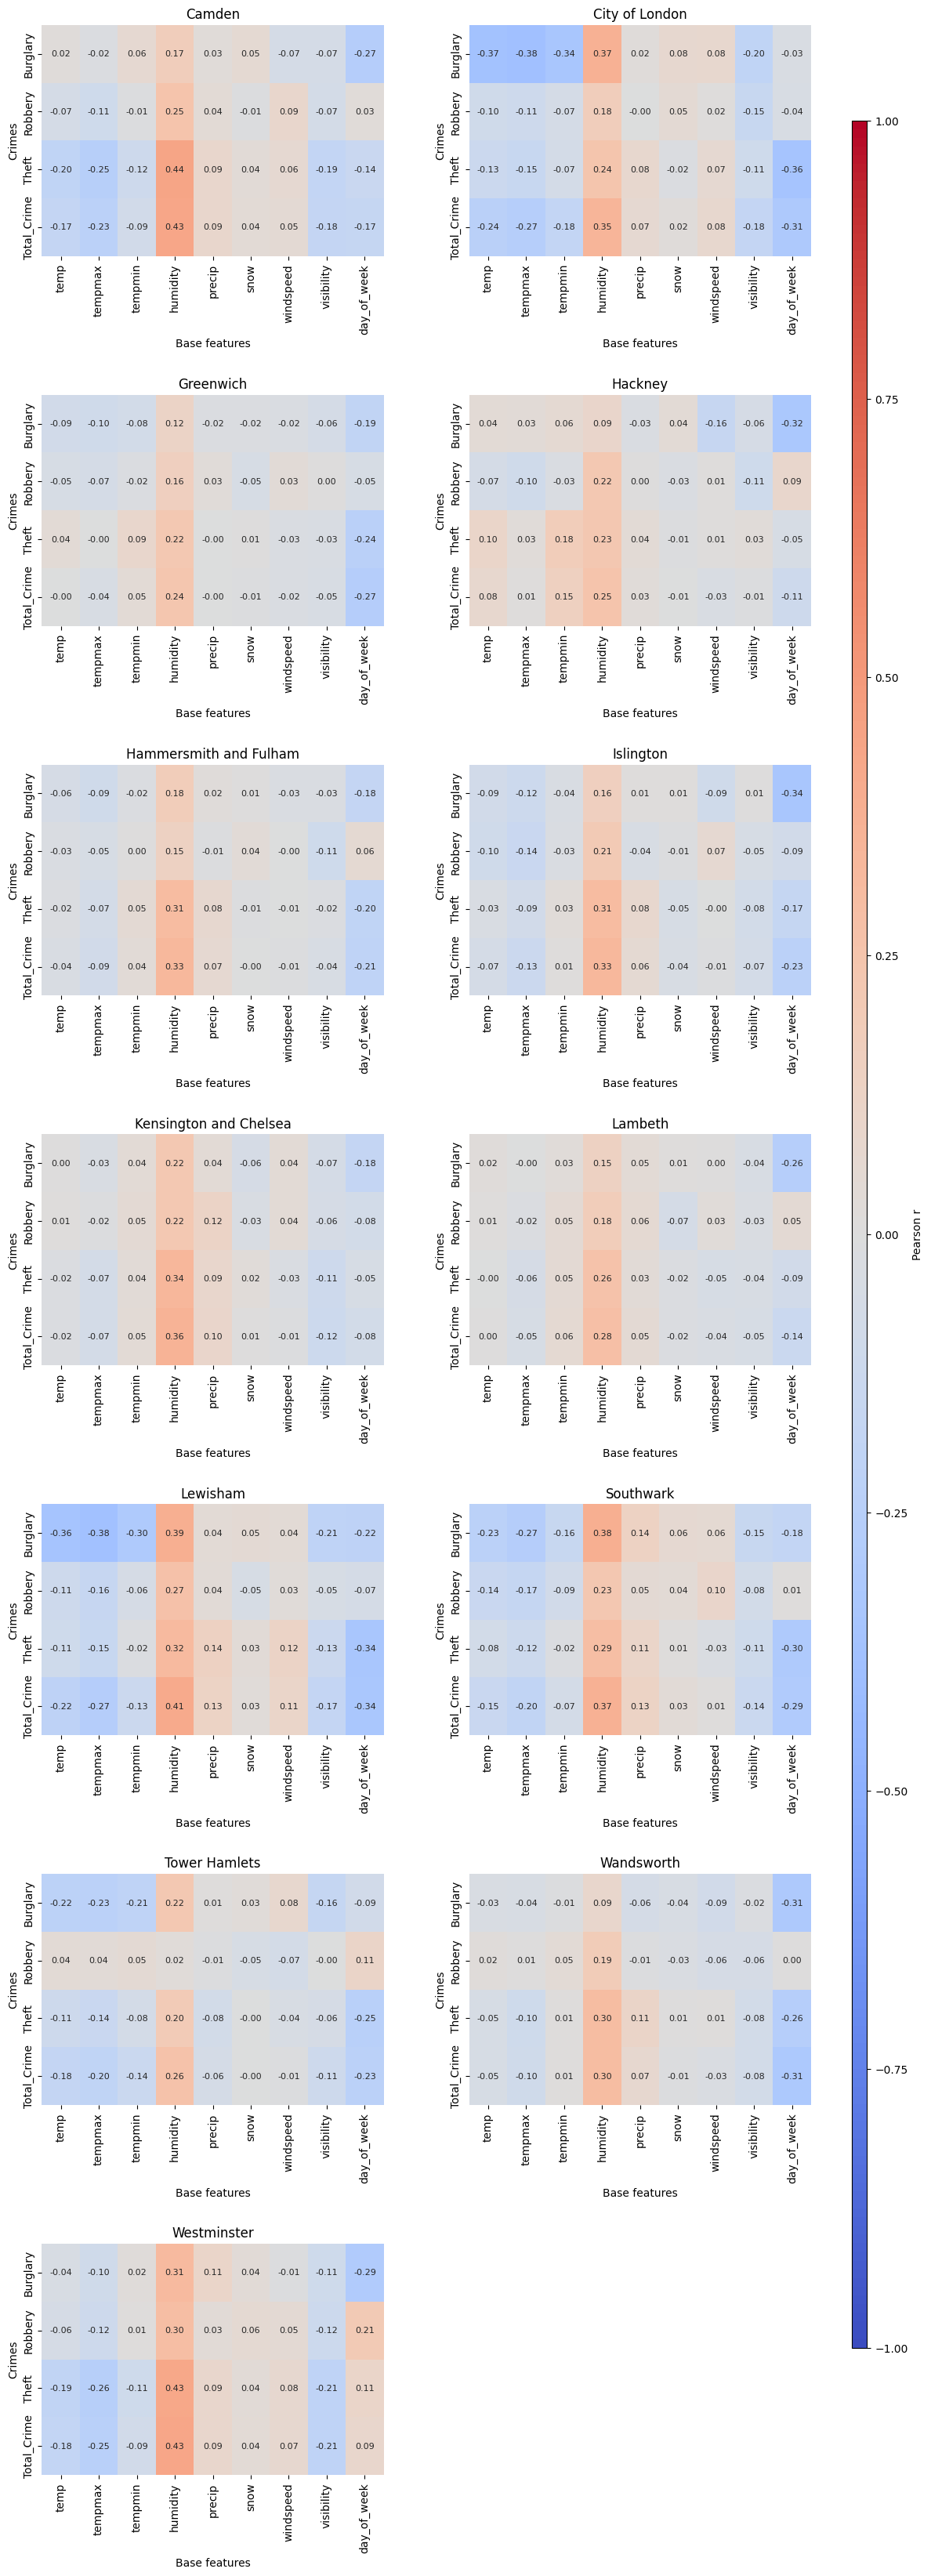

,Borough,Crime,temp,tempmax,tempmin,humidity,precip,snow,windspeed,visibility,day_of_week
0,Camden,Burglary,0.017809,-0.020896,0.062898,0.174189,0.029417,0.054900,-0.067500,-0.066633,-0.272373
1,Camden,Robbery,-0.066682,-0.108243,-0.010994,0.253041,0.040365,-0.014999,0.089516,-0.071509,0.027175
2,Camden,Theft,-0.197222,-0.252964,-0.116639,0.438243,0.092594,0.038229,0.063425,-0.187209,-0.143806
3,Camden,Total_Crime,-0.172406,-0.231433,-0.089481,0.432690,0.088557,0.040087,0.053062,-0.179053,-0.165702
4,City of London,Burglary,-0.374344,-0.384228,-0.339046,0.371303,0.022854,0.077407,0.081708,-0.202567,-0.034835
5,City of London,Robbery,-0.096106,-0.114190,-0.067319,0.176528,-0.003804,0.049039,0.015468,-0.150821,-0.042391
6,City of London,Theft,-0.125383,-0.151145,-0.073893,0.244676,0.078336,-0.021316,0.069357,-0.109043,-0.358176
7,City of London,Total_Crime,-0.238045,-0.265170,-0.180142,0.347415,0.069824,0.016263,0.084847,-0.179422,-0.307442
8,Greenwich,Burglary,-0.093171,-0.098021,-0.081240,0.118649,-0.021443,-0.018917,-0.023733,-0.062855,-0.194353
9,Greenwich,Robbery,-0.050996,-0.069976,-0.022979,0.157837,0.025210,-0.048600,0.032827,0.000657,-0.049892


In [43]:
# Inputs 
base_features = ["temp", "tempmax", "tempmin", "humidity", "precip", "snow", "windspeed", "visibility", "day_of_week"]
crime_types   = ["Burglary", "Robbery", "Theft", "Total_Crime"]

boroughs = sorted(df["Borough"].unique())
n = len(boroughs)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(6.5 * cols, 5.8 * rows),  
    sharex=False, sharey=False
)
axes = np.array(axes).reshape(rows, cols)

correlation_summary = []
all_vals = []

# Collect all correlation values for global color scaling
for borough in boroughs:
    borough_df = df[df["Borough"] == borough]
    corr = borough_df[base_features + crime_types].corr()
    block = corr.loc[crime_types, base_features].values.flatten()
    all_vals.append(block)

all_vals = np.concatenate(all_vals)
vmin, vmax = -1, 1  

k = 0
for r in range(rows):
    for c in range(cols):
        ax = axes[r, c]
        if k < n:
            borough = boroughs[k]
            borough_df = df[df["Borough"] == borough]
            corr = borough_df[base_features + crime_types].corr()
            corr_block = corr.loc[crime_types, base_features]

            sns.heatmap(
                corr_block,
                ax=ax,
                annot=True,
                fmt=".2f",
                cmap="coolwarm",
                vmin=vmin, vmax=vmax,
                cbar=False,
                annot_kws={"size": 8}
            )
            ax.set_title(borough, pad=6)
            ax.set_xlabel("Base features")
            ax.set_ylabel("Crimes")

            # add to summary table
            for crime in crime_types:
                row = {"Borough": borough, "Crime": crime}
                for feat in base_features:
                    row[feat] = corr_block.loc[crime, feat]
                correlation_summary.append(row)
        else:
            ax.axis("off")
        k += 1

# Shared colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
mappable = plt.cm.ScalarMappable(cmap="coolwarm")
mappable.set_array(all_vals)
mappable.set_clim(vmin, vmax)
fig.colorbar(mappable, cax=cbar_ax, label="Pearson r")

# Adjust spacing ---
fig.subplots_adjust(
    right=0.88,
    wspace=0.25,   # horizontal space between columns
    hspace=0.6     # vertical space between rows (increase this to get more gaps)
)

plt.savefig("borough_correlation_heatmaps_2col_spaced.png", dpi=300, bbox_inches="tight")
plt.show()

# Build summary dataframe
correlation_df = pd.DataFrame(correlation_summary)
correlation_df